In [1]:
# Data 가져오기 + 데이터 분류 - Fashion MNIST
from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

# 정규화
train_scaled = train_input / 255.0

# train 과 valid data 생성
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [4]:
# Model 함수
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28, 28)))
    model.add(keras.layers.Dense(100, activation='relu'))
    if a_layer:
        model.add(a_layer)
    model.add(keras.layers.Dense(10, activation='softmax', name='output'))
    return model

In [5]:
# 모델 구성 및 summary
model = model_fn()
model.summary()

c:\Users\tuxca\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 훈련 및 과정에 대한 history 보기
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8121 - loss: 0.5293
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8594 - loss: 0.3892
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8729 - loss: 0.3535
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8819 - loss: 0.3300
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8851 - loss: 0.3145


In [8]:
# history 내에는 accuracy와 loss값이 들어가 있다
history.history.keys()

dict_keys(['accuracy', 'loss'])

#### 손실곡선

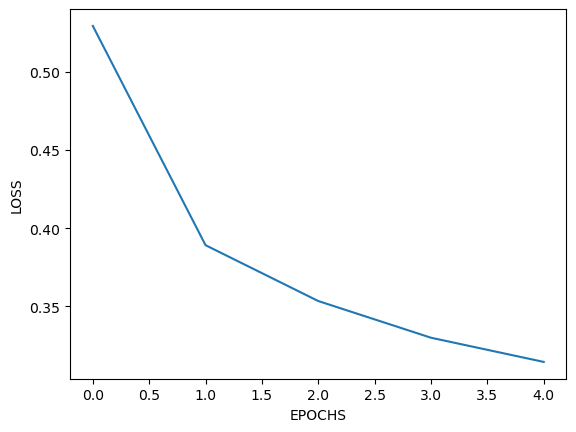

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('EPOCHS')
plt.ylabel('LOSS')

plt.show()

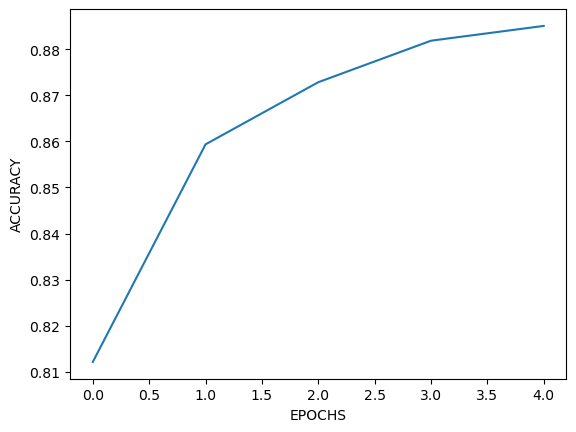

In [10]:
plt.plot(history.history['accuracy'])
plt.xlabel('EPOCHS')
plt.ylabel('ACCURACY')

plt.show()

> 가설 : epochs를 늘리면 정확도가 더 올라가고 손실이 더 떨어질 것 같다

----
#### 반복 훈련의 횟수 증가(epochs 증가)

In [14]:
model = model_fn()
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_scaled, train_target, epochs=20)

Epoch 1/20


c:\Users\tuxca\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8101 - loss: 0.5374
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8594 - loss: 0.3932
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8731 - loss: 0.3549
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8813 - loss: 0.3317
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8877 - loss: 0.3151
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8909 - loss: 0.3038
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8959 - loss: 0.2959
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8996 - loss: 0.2866
Epoch 9/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9018 - loss: 0.2777
Epoch 10/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9033 - loss: 0.2730
Epoch 11/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9066 - loss: 0.2687
Epoch 12/20
1500/1500 ━━━━━━━━━━━━━━━━━━━

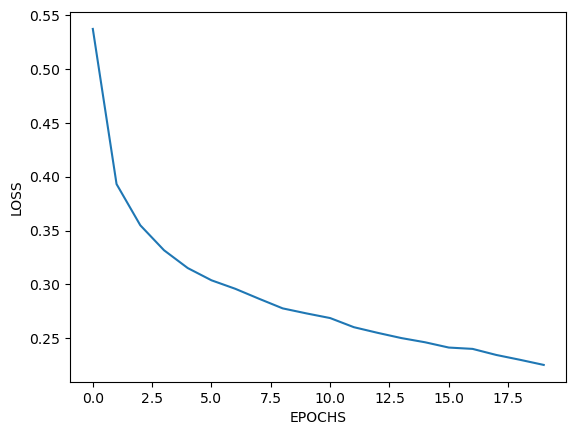

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('EPOCHS')
plt.ylabel('LOSS')

plt.show()

---
#### 검증 손실
: 검증세트에 대한 정확도를 파악하자

In [18]:
model = model_fn()
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data=(val_scaled, val_target)
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8108 - loss: 0.5320 - val_accuracy: 0.8450 - val_loss: 0.4302
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8582 - loss: 0.3937 - val_accuracy: 0.8554 - val_loss: 0.3982
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8704 - loss: 0.3569 - val_accuracy: 0.8711 - val_loss: 0.3667
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8796 - loss: 0.3344 - val_accuracy: 0.8756 - val_loss: 0.3558
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8849 - loss: 0.3159 - val_accuracy: 0.8728 - val_loss: 0.3694
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8899 - loss: 0.3048 - val_accuracy: 0.8742 - val_loss: 0.3808
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8947 - loss: 0.2961 - val_accuracy: 0.8745 - val_loss: 0.3656
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8978 - loss: 0.2869 - 

In [20]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

TypeError: 'function' object is not subscriptable

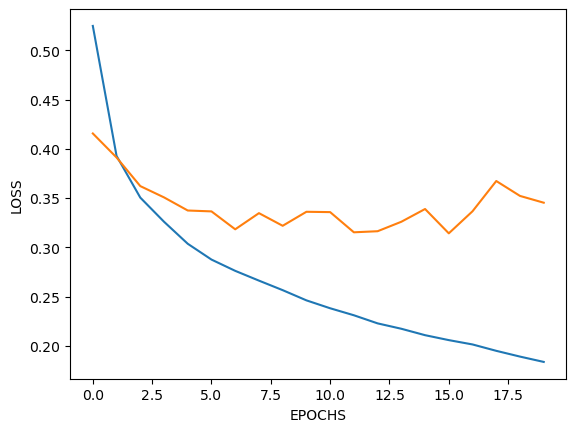

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('EPOCHS')
plt.ylabel('LOSS')
# plt.legend['train, val']

plt.show()

> 훈련세트는 epochs가 증가됨에 따라 손실이 떨어지고 있으나,     
>  검증세트는 epochs가 증가됨에 따라 초반에는 손실이 떨어지나, 진행하면 할 수록 손실율이 증가함.
?  이 모델은 훈련세트의 정확도가 높아 좋지만 검증 세트에는 적합하지 않은 과대 적합 모델이다.

---
Optimizer 사용

In [23]:
model = model_fn()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data=(val_scaled, val_target)
)

c:\Users\tuxca\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8175 - loss: 0.5247 - val_accuracy: 0.8532 - val_loss: 0.4155
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8593 - loss: 0.3927 - val_accuracy: 0.8583 - val_loss: 0.3911
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8735 - loss: 0.3504 - val_accuracy: 0.8721 - val_loss: 0.3621
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8807 - loss: 0.3259 - val_accuracy: 0.8706 - val_loss: 0.3506
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8880 - loss: 0.3036 - val_accuracy: 0.8788 - val_loss: 0.3373
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8938 - loss: 0.2875 - val_accuracy: 0.8800 - val_loss: 0.3364
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8979 - loss: 0.2761 - val_accuracy: 0.8868 - val_loss: 0.3182
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9025 - loss: 0.2661 - 

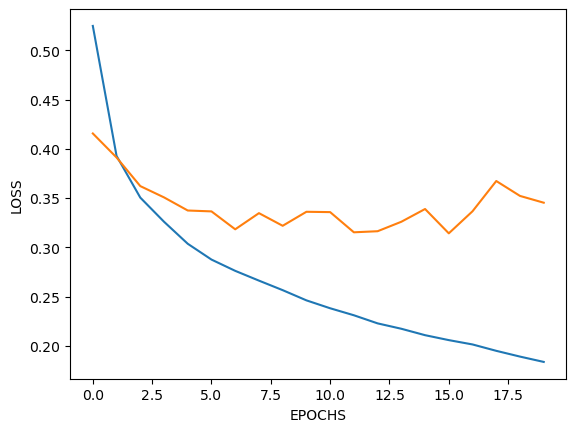

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('EPOCHS')
plt.ylabel('LOSS')

plt.show()

> optimizer(최적화 알고리즘)을 사용해서 train과 valid의 손실율이 조금 더 비슷해지고,       
> valid의 손실율이 안정되었으나 아직 과대적합이다

> 과대적합을 줄이기 위해서 '규제'를 건다

----
#### Dropout
: 훈련 시 각 데이터를 처리할 때 데이터의 갯수를 랜덤으로 줄인다.

In [27]:
# model에 dropout을 추가
model = model_fn(keras.layers.Dropout(0.3)) # %를 입력함
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data=(val_scaled, val_target)
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7891 - loss: 0.5989 - val_accuracy: 0.8443 - val_loss: 0.4265
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8394 - loss: 0.4424 - val_accuracy: 0.8571 - val_loss: 0.3922
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8533 - loss: 0.4054 - val_accuracy: 0.8543 - val_loss: 0.3955
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8600 - loss: 0.3831 - val_accuracy: 0.8667 - val_loss: 0.3590
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8650 - loss: 0.3697 - val_accuracy: 0.8712 - val_loss: 0.3481
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8692 - loss: 0.3575 - val_accuracy: 0.8777 - val_loss: 0.3378
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8721 - loss: 0.3463 - val_accuracy: 0.8708 - val_loss: 0.3558
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8748 - loss: 0.3365 - 

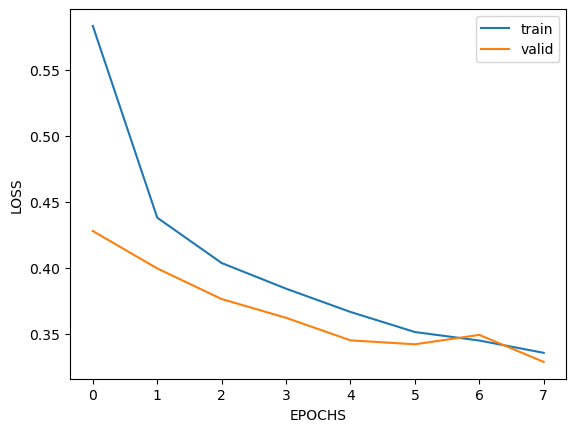

In [33]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('EPOCHS')
plt.ylabel('LOSS')
plt.legend(['train','valid'])

plt.show()

> Epochs가 9일 경우 train과 valid의 차이가 적은 것 같다.    
> 기본적으로 훈련세트의 손실이 검증세트보다 적게 나오는 epochs를 선택

In [37]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_scaled,
    train_target,
    epochs=9,
    validation_data=(val_scaled, val_target)
)

Epoch 1/9


c:\Users\tuxca\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7924 - loss: 0.5913 - val_accuracy: 0.8430 - val_loss: 0.4389
Epoch 2/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8428 - loss: 0.4378 - val_accuracy: 0.8587 - val_loss: 0.3837
Epoch 3/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8543 - loss: 0.4031 - val_accuracy: 0.8691 - val_loss: 0.3617
Epoch 4/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8628 - loss: 0.3813 - val_accuracy: 0.8720 - val_loss: 0.3480
Epoch 5/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8650 - loss: 0.3673 - val_accuracy: 0.8682 - val_loss: 0.3595
Epoch 6/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8716 - loss: 0.3496 - val_accuracy: 0.8717 - val_loss: 0.3474
Epoch 7/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8742 - loss: 0.3418 - val_accuracy: 0.8728 - val_loss: 0.3457
Epoch 8/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8756 - loss: 0.3328 - val_accuracy: 0.87

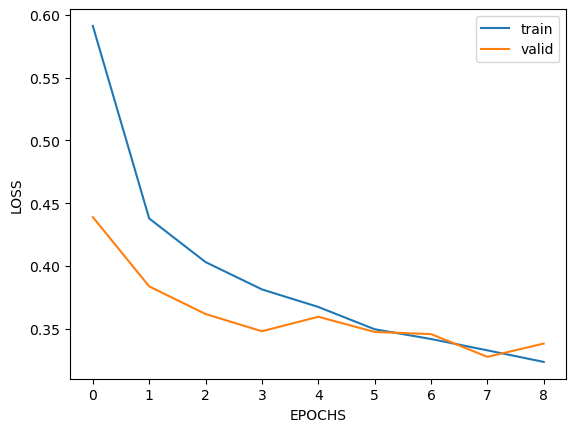

In [38]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('EPOCHS')
plt.ylabel('LOSS')
plt.legend(['train','valid'])

plt.show()

#### 모델의 저장과 복원

In [39]:
# 모델의 저장
model.save('../Data/model_fashion.keras')

In [40]:
# 복원 - 추후 fastAPI
model1 = keras.models.load_model('../Data/model_fashion.keras')

In [41]:
model1.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8798 - loss: 0.3382


[0.338166743516922, 0.8798333406448364]

----
#### Callbacks
: 훈련수행 시 손실값이 제일 작은 모델을 저장해준다 <- 굉장히 편하다

In [42]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_model.keras')

history = model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb]
)

Epoch 1/20


c:\Users\tuxca\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7912 - loss: 0.5935 - val_accuracy: 0.8510 - val_loss: 0.4264
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8420 - loss: 0.4397 - val_accuracy: 0.8612 - val_loss: 0.3786
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8533 - loss: 0.4047 - val_accuracy: 0.8623 - val_loss: 0.3736
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8615 - loss: 0.3790 - val_accuracy: 0.8712 - val_loss: 0.3527
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8646 - loss: 0.3678 - val_accuracy: 0.8737 - val_loss: 0.3450
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8694 - loss: 0.3529 - val_accuracy: 0.8818 - val_loss: 0.3315
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8749 - loss: 0.3436 - val_accuracy: 0.8766 - val_loss: 0.3383
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8750 - loss: 0.3351 - val_accurac

In [ ]:
# 복원 - 추후 fastAPI
model2 = keras.models.load_model('../Data/best_model.keras')

In [ ]:
# 사용
model2.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8870 - loss: 0.3292


[0.3292388319969177, 0.8870000243186951]

----
#### Early-Stopping (조기종료)
: Callbacks를 끝까지 기다리는 것이 아니고 patience(Hyper Parameter)을 선정하여 한계값을 정해 실행한다

In [45]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_model.keras')
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/20


c:\Users\tuxca\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7912 - loss: 0.5909 - val_accuracy: 0.8436 - val_loss: 0.4371
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8429 - loss: 0.4372 - val_accuracy: 0.8602 - val_loss: 0.3806
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8531 - loss: 0.4019 - val_accuracy: 0.8609 - val_loss: 0.3799
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8603 - loss: 0.3813 - val_accuracy: 0.8709 - val_loss: 0.3610
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8683 - loss: 0.3611 - val_accuracy: 0.8720 - val_loss: 0.3506
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8690 - loss: 0.3557 - val_accuracy: 0.8786 - val_loss: 0.3398
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8731 - loss: 0.3435 - val_accuracy: 0.8738 - val_loss: 0.3396
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8750 - loss: 0.3376 - val_accurac

In [46]:
# 몇 번째 epoch에서 stop 되었는가?
early_stopping_cb.stopped_epoch

8

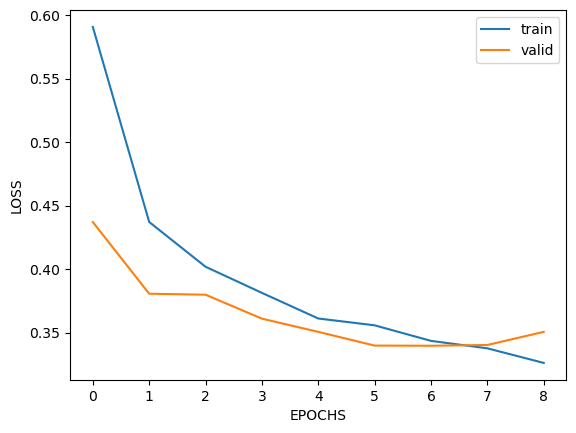

In [47]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('EPOCHS')
plt.ylabel('LOSS')
plt.legend(['train','valid'])

plt.show()

In [48]:
model3 = keras.models.load_model('../Data/best_model.keras')
model3.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8756 - loss: 0.3506


[0.35059207677841187, 0.8755833506584167]